# Task

In [322]:
import pandas as pd
import numpy as np

In [323]:
df = pd.read_csv('glass.csv')

In [324]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [325]:
df.shape

(214, 10)

In [326]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['Type']),df['Type'],test_size=0.2,random_state=2)

In [327]:
X_train.sample(5)

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
178,1.51829,14.46,2.24,1.62,72.38,0.00,9.26,0.0,0.00
138,1.51674,12.79,3.52,1.54,73.36,0.66,7.90,0.0,0.00
92,1.51588,13.12,3.41,1.58,73.26,0.07,8.39,0.0,0.19
156,1.51655,13.41,3.39,1.28,72.64,0.52,8.65,0.0,0.00
87,1.51645,13.40,3.49,1.52,72.65,0.67,8.08,0.0,0.10


In [328]:
y_train.sample(4)

,Type
195,7
22,1
130,2
111,2


In [329]:
from sklearn.preprocessing import StandardScaler

In [330]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [331]:
X_train

array([[-0.72333174,  0.10969725,  0.60674727, ..., -0.86643887,
        -0.35407712, -0.573292  ],
       [-0.42662953,  0.94128435, -1.86010645, ..., -0.26907265,
         3.21128975, -0.573292  ],
       [-0.25116048, -0.27045686,  0.70403164, ..., -0.55353275,
        -0.35407712, -0.573292  ],
       ...,
       [-0.80309039, -0.41301465,  0.6345428 , ..., -0.83088136,
        -0.35407712, -0.573292  ],
       [-0.26711221, -0.74564949,  0.59979838, ..., -0.43263721,
        -0.35407712, -0.573292  ],
       [-0.57019511, -0.68625041, -1.86010645, ...,  0.83321027,
        -0.35407712, -0.573292  ]])

In [332]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=14)

In [333]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=14)

In [334]:
y_pred=knn.predict(X_test)

In [335]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7674418604651163

In [336]:
scores=[]

for i in range(1,20):
  knn=KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train,y_train)
  y_pred = knn.predict(X_test)
  scores.append(accuracy_score(y_test,y_pred))

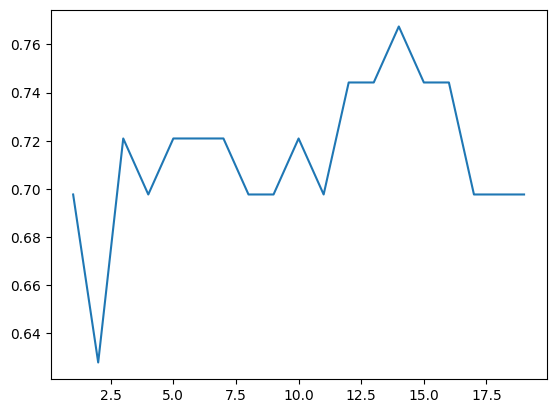

In [337]:
import matplotlib.pyplot as plt

plt.plot(range(1,20),scores)